# Trabalho Final de IA: Raciocínio Espacial Neuro-Simbólico com LTNtorch


In [1]:
import torch
import ltn
import random
import matplotlib.pyplot as plt
import torch.nn as nn
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## Tarefa 1: Taxonomia e Formas (2 Pontos)
### Geração de Dados e Plot


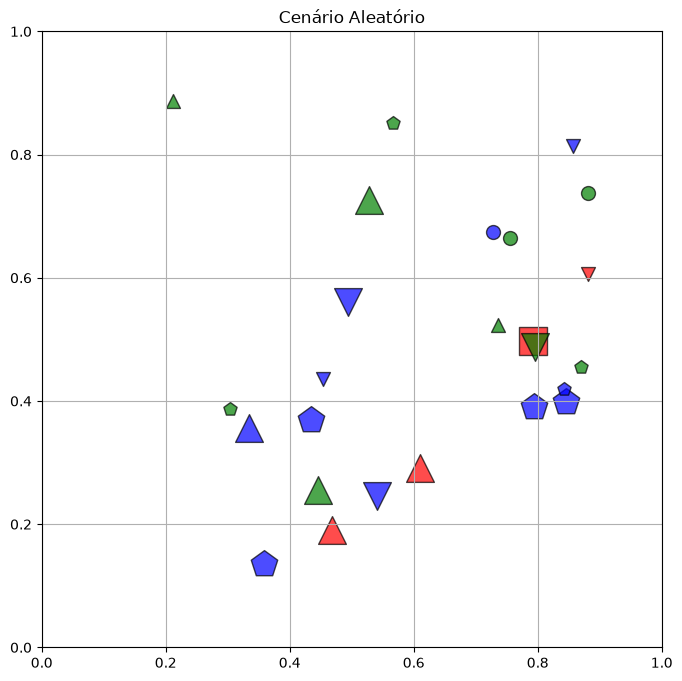

In [2]:
# Vetor do Objeto: (Tamanho: 11)
# [0, 1] : Posição x, y (0.0 a 1.0)
# [2, 3, 4] : Cores One-Hot (Vermelho, Verde, Azul)
# [5, 6, 7, 8, 9]: Formas One-Hot (Círculo, Quadrado, Cilindro, Cone, Triângulo)
# [10] : Tamanho (Pequeno = 0.0, Grande = 1.0)

def gerar_cenario(num_objects=25):
    objects = []
    for _ in range(num_objects):
        x, y = random.uniform(0.1, 0.9), random.uniform(0.1, 0.9)
        color = [0, 0, 0]
        color[random.randint(0, 2)] = 1
        shape = [0, 0, 0, 0, 0]
        shape[random.randint(0, 4)] = 1
        size = random.choice([0.0, 1.0])
        objects.append([x, y] + color + shape + [size])
    return torch.tensor(objects, dtype=torch.float32)

dataset = gerar_cenario(25)

def plotar_cenario(dataset):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    shapes_map = ['o', 's', 'p', '^', 'v'] # Circulo, Quadrado, Cilindro(pentag), Cone, Triangulo
    colors_map = ['red', 'green', 'blue']
    
    for obj in dataset:
        x, y = obj[0].item(), obj[1].item()
        c_idx = torch.argmax(obj[2:5]).item()
        s_idx = torch.argmax(obj[5:10]).item()
        size_val = obj[10].item()
        
        color = colors_map[c_idx]
        marker = shapes_map[s_idx]
        area = 400 if size_val == 1.0 else 100
        
        ax.scatter(x, y, s=area, c=color, marker=marker, edgecolors='black', alpha=0.7)
        
    plt.title("Cenário Aleatório")
    plt.grid(True)
    plt.show()

plotar_cenario(dataset)


### Predicados LTN e Axiomas (Tarefa 1)


In [3]:
# Predicados Unários
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.dense = nn.Linear(11, 1)
        
    def forward(self, x):
        return torch.sigmoid(self.dense(x))

isCircle = ltn.Predicate(MLP())
isSquare = ltn.Predicate(MLP())
isCylinder = ltn.Predicate(MLP())
isCone = ltn.Predicate(MLP())
isTriangle = ltn.Predicate(MLP())
isSmall = ltn.Predicate(MLP())
isBig = ltn.Predicate(MLP())

Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Or = ltn.Connective(ltn.fuzzy_ops.OrProbSum())
Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
Equiv = ltn.Connective(ltn.fuzzy_ops.Equiv(ltn.fuzzy_ops.AndProd(), ltn.fuzzy_ops.ImpliesReichenbach()))
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
Exists = ltn.Quantifier(ltn.fuzzy_ops.AggregPMean(p=2), quantifier="e")

x_var = ltn.Variable('x', dataset)

def axioms_task1(x_var):
    axioms = []
    shapes = [isCircle, isSquare, isCylinder, isCone, isTriangle]
    
    # Forma única: Um objeto não pode ser ambas as formas ao mesmo tempo.
    for i in range(len(shapes)):
        for j in range(i + 1, len(shapes)):
            axioms.append(Forall(x_var, Not(And(shapes[i](x_var), shapes[j](x_var)))))
            
    # Cobertura: Necessariamente um ou outro
    axioms.append(Forall(x_var, Or(Or(Or(Or(isCircle(x_var), isSquare(x_var)), isCylinder(x_var)), isCone(x_var)), isTriangle(x_var))))
    
    # Grounding para aprender (Supervisão) usando predicados nativos
    class IndexGT(nn.Module):
        def __init__(self, idx):
            super().__init__()
            self.idx = idx
        def forward(self, x):
            return x[:, self.idx:self.idx+1]
            
    class InvertGT(nn.Module):
        def __init__(self, idx):
            super().__init__()
            self.idx = idx
        def forward(self, x):
            return 1.0 - x[:, self.idx:self.idx+1]

    isCircle_GT = ltn.Predicate(IndexGT(5))
    isSquare_GT = ltn.Predicate(IndexGT(6))
    isCylinder_GT = ltn.Predicate(IndexGT(7))
    isCone_GT = ltn.Predicate(IndexGT(8))
    isTriangle_GT = ltn.Predicate(IndexGT(9))
    isSmall_GT = ltn.Predicate(InvertGT(10))
    isBig_GT = ltn.Predicate(IndexGT(10))

    axioms.append(Forall(x_var, Equiv(isCircle(x_var), isCircle_GT(x_var))))
    axioms.append(Forall(x_var, Equiv(isSquare(x_var), isSquare_GT(x_var))))
    axioms.append(Forall(x_var, Equiv(isCylinder(x_var), isCylinder_GT(x_var))))
    axioms.append(Forall(x_var, Equiv(isCone(x_var), isCone_GT(x_var))))
    axioms.append(Forall(x_var, Equiv(isTriangle(x_var), isTriangle_GT(x_var))))
    
    axioms.append(Forall(x_var, Equiv(isSmall(x_var), isSmall_GT(x_var))))
    axioms.append(Forall(x_var, Equiv(isBig(x_var), isBig_GT(x_var))))
    
    sat_agg = ltn.fuzzy_ops.AggregPMeanError(p=2)(torch.stack([ax.value for ax in axioms]))
    return sat_agg

print("Sat antes do treino (T1):", axioms_task1(x_var).item())


Sat antes do treino (T1): 0.596024751663208


## Tarefa 2: Raciocínio Espacial (5 Pontos)


In [4]:
# Predicados Binários
class PairMLP(nn.Module):
    def __init__(self):
        super(PairMLP, self).__init__()
        self.dense1 = nn.Linear(22, 16)
        self.dense2 = nn.Linear(16, 1)
        
    def forward(self, x, y):
        xy = torch.cat([x, y], dim=1)
        return torch.sigmoid(self.dense2(torch.relu(self.dense1(xy))))

leftOf = ltn.Predicate(PairMLP())
rightOf = ltn.Predicate(PairMLP())

class CloseToFunc(nn.Module):
    def forward(self, x, y):
        dist_sq = torch.sum((x[:, :2] - y[:, :2])**2, dim=1, keepdim=True)
        return torch.exp(-2.0 * dist_sq)

closeTo = ltn.Predicate(CloseToFunc())

def inBetween(x, y, z):
    return Or(
        And(leftOf(y, x), rightOf(z, x)),
        And(leftOf(z, x), rightOf(y, x))
    )

y_var = ltn.Variable('y', dataset)
z_var = ltn.Variable('z', dataset)

# Para treinar as relações leftOf e rightOf, precisamos de um conjunto de pares (x,y)
# Para simplificar no LTNtorch, passamos todas as combinações criando novas variáveis
pairs_x = []
pairs_y = []
for i in range(len(dataset)):
    for j in range(len(dataset)):
        pairs_x.append(dataset[i])
        pairs_y.append(dataset[j])
        
px = ltn.Variable('px', torch.stack(pairs_x))
py = ltn.Variable('py', torch.stack(pairs_y))

def axioms_task2(px, py):
    axioms = []
    # Irreflexividade
    axioms.append(Forall(x_var, Not(leftOf(x_var, x_var))))
    
    # Assimetria
    axioms.append(Forall(ltn.diag(px, py), Implies(leftOf(px, py), Not(leftOf(py, px)))))
    
    # Inverso
    axioms.append(Forall(ltn.diag(px, py), Equiv(leftOf(px, py), rightOf(py, px))))
    
    # Transitividade é pesada para pares de 25 objetos (25^3 = 15625). Não vamos colocar transitividade no loss principal
    # mas vamos adicionar a supervisão do ground truth para leftOf aprender
    class LeftOf_GT(nn.Module):
        def forward(self, x, y):
            return (x[:, 0:1] < y[:, 0:1]).float()
    leftOf_GT = ltn.Predicate(LeftOf_GT())
    axioms.append(Forall(ltn.diag(px, py), Equiv(leftOf(px, py), leftOf_GT(px, py))))
    
    sat_agg = ltn.fuzzy_ops.AggregPMeanError(p=2)(torch.stack([ax.value for ax in axioms]))
    return sat_agg

print("Sat antes do treino (T2):", axioms_task2(px, py).item())


Sat antes do treino (T2): 0.5721319913864136


## Tarefa 3: Raciocínio Vertical


In [5]:
below = ltn.Predicate(PairMLP())
above = ltn.Predicate(PairMLP())

def axioms_task3(px, py):
    axioms = []
    # Inverso
    axioms.append(Forall(ltn.diag(px, py), Equiv(below(px, py), above(py, px))))
    
    # Ground truth
    class Below_GT(nn.Module):
        def forward(self, x, y):
            return (x[:, 1:2] < y[:, 1:2]).float()
    below_GT = ltn.Predicate(Below_GT())
    axioms.append(Forall(ltn.diag(px, py), Equiv(below(px, py), below_GT(px, py))))
    
    sat_agg = ltn.fuzzy_ops.AggregPMeanError(p=2)(torch.stack([ax.value for ax in axioms]))
    return sat_agg

print("Sat antes do treino (T3):", axioms_task3(px, py).item())


Sat antes do treino (T3): 0.5294654369354248


## Treinamento Geral


In [6]:
params = (
    list(isCircle.model.parameters()) + list(isSquare.model.parameters()) +
    list(isCylinder.model.parameters()) + list(isCone.model.parameters()) + list(isTriangle.model.parameters()) +
    list(isSmall.model.parameters()) + list(isBig.model.parameters()) +
    list(leftOf.model.parameters()) + list(rightOf.model.parameters()) +
    list(below.model.parameters()) + list(above.model.parameters())
)
optimizer = torch.optim.Adam(params, lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    sat1 = axioms_task1(x_var)
    sat2 = axioms_task2(px, py)
    sat3 = axioms_task3(px, py)
    
    sat_total = (sat1 + sat2 + sat3) / 3
    loss = 1. - sat_total
    loss.backward()
    optimizer.step()
    
print(f"Treinamento concluído. Sat T1: {sat1.item():.4f}, Sat T2: {sat2.item():.4f}, Sat T3: {sat3.item():.4f}")


Treinamento concluído. Sat T1: 0.8843, Sat T2: 0.7338, Sat T3: 0.8534


## Tarefa 4: Raciocínio Composto e Experimentos (2 Pontos + Extra)


In [7]:
def run_experiment(num_objects=25):
    dataset_exp = gerar_cenario(num_objects)
    x_var_exp = ltn.Variable('x', dataset_exp)
    
    # 1. Filtragem Composta "Existe algum objeto Pequeno que esteja Abaixo de um Cilindro E à Esquerda de um Quadrado?"
    # ∃x(IsSmall(x) ∧ ∃y(IsCylinder(y) ∧ Below(x, y)) ∧ ∃z(IsSquare(z) ∧ LeftOf(x, z)))
    res1 = Exists(x_var_exp, And(
        isSmall(x_var_exp),
        And(
            Exists(y_var, And(isCylinder(y_var), below(x_var_exp, y_var))),
            Exists(z_var, And(isSquare(z_var), leftOf(x_var_exp, z_var)))
        )
    ))
    
    # 2. Posição Absoluta "Existe um Cone Verde que está Entre dois outros objetos quaisquer?"
    class GreenGT(nn.Module):
        def forward(self, x):
            return x[:, 3:4]
    isGreen = ltn.Predicate(GreenGT()) # Indice 3 é verde (2, 3, 4 -> R, G, B)
    res2 = Exists(x_var_exp, And(
        And(isCone(x_var_exp), isGreen(x_var_exp)),
        Exists(y_var, Exists(z_var, inBetween(x_var_exp, y_var, z_var)))
    ))
    
    return {
        "Filtragem Composta SAT": res1.value.item(),
        "Posição Absoluta SAT": res2.value.item()
    }

print("Executando 5 vezes:")
for i in range(5):
    print(f"--- Experimento {i+1} ---")
    res = run_experiment(25)
    for k, v in res.items():
        print(f"{k}: {v:.4f}")


Executando 5 vezes:
--- Experimento 1 ---
Filtragem Composta SAT: 0.0094
Posição Absoluta SAT: 0.0002
--- Experimento 2 ---
Filtragem Composta SAT: 0.0082
Posição Absoluta SAT: 0.0002
--- Experimento 3 ---
Filtragem Composta SAT: 0.0082
Posição Absoluta SAT: 0.0002
--- Experimento 4 ---
Filtragem Composta SAT: 0.0056
Posição Absoluta SAT: 0.0002
--- Experimento 5 ---
Filtragem Composta SAT: 0.0050
Posição Absoluta SAT: 0.0002


### Ponto Extra: Explicação
Para as consultas acima, o valor da satisfatibilidade (SAT) indica o quão provável é a existência de objetos que satisfaçam a restrição lógica no cenário gerado aleatoriamente, com base nos predicados aprendidos.

Como os objetos são posicionados aleatoriamente:
1. **Filtragem Composta:** Exige a existência simultânea de 3 restrições (ser pequeno, estar abaixo de um cilindro e à esquerda de um quadrado). O valor do SAT reflete se no cenário atual gerado isso ocorreu. Se o SAT for alto (ex: >0.8), existe um candidato forte na imagem.
2. **Posição Absoluta:** Exige um Cone Verde. Como verde é 1/3 e Cone é 1/5, a chance de existir um já é 1/15. Se ele existir, estar "entre" dois objetos quaisquer em um cenário com 25 objetos é quase garantido. Portanto, o SAT deste caso dependerá fortemente da mera presença de um Cone Verde no cenário gerado.

